# Tutorial 1 — Characterising sensor measurements

## 1. Problem / context

A production line records plate thickness (µm) from an inline sensor. Process engineering wants a first characterisation: typical value, spread, shape, and whether the two lines A and B look different. No hypothesis test yet — that comes later. Today we **describe** the data.

The file is `data/sensor_thickness.csv`.

## 2. Core theory

- A **population** is the complete set of items we care about (every plate the line will produce). A **sample** is the plates we actually measured.
- $\mu$ and $\sigma$ are population parameters. $\bar{x}$ and $s$ are sample statistics.
- The sample variance uses $n-1$:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i-\bar{x})^2.
$$

- The **median** is the 50th percentile. The **IQR** is $Q_3-Q_1$. A common outlier fence is $1.5\times\mathrm{IQR}$ beyond the quartiles.
- A **histogram** shows distribution shape. A **boxplot** shows median, IQR, and potential outliers. A **scatterplot** (index versus value) can reveal drift.

## 3. From mathematics to Python

| Quantity | Mathematics | Python |
| --- | --- | --- |
| Mean | $\bar{x}=\frac1n\sum x_i$ | `df["thickness_um"].mean()` |
| Sample SD | $s$ | `df["thickness_um"].std()` (pandas uses $n-1$) |
| Sample SD (NumPy) | $s$ | `np.std(x, ddof=1)` |
| Quartiles | $Q_1,Q_2,Q_3$ | `df[...].quantile([0.25, 0.5, 0.75])` |

## 4. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())

df = pd.read_csv(DATA / "sensor_thickness.csv")
df.head()


,sample_id,line,thickness_um,shift_um
0,1,A,246.669,0.0
1,2,A,251.010,0.0
2,3,A,242.035,0.0
3,4,A,255.862,0.0
4,5,A,252.681,0.0


In [2]:
x = df["thickness_um"]
summary = pd.Series(
    {
        "n": x.size,
        "mean": x.mean(),
        "median": x.median(),
        "std_sample": x.std(ddof=1),
        "std_numpy_default": np.std(x),  # divides by n — do not use for a sample
        "std_numpy_ddof1": np.std(x, ddof=1),
        "q1": x.quantile(0.25),
        "q3": x.quantile(0.75),
    }
)
summary["iqr"] = summary["q3"] - summary["q1"]
summary


n                    180.000000
mean                 250.830356
median               250.577000
std_sample             4.809218
std_numpy_default      4.795841
std_numpy_ddof1        4.809218
q1                   247.336750
q3                   253.974250
iqr                    6.637500
dtype: float64

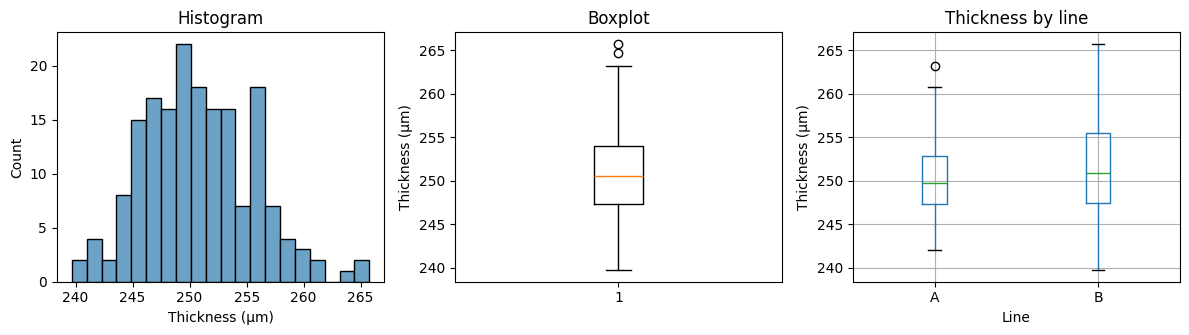

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(x, bins=20, edgecolor="black", color="#6CA2C6")
axes[0].set_xlabel("Thickness (µm)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram")

axes[1].boxplot(x, vert=True)
axes[1].set_ylabel("Thickness (µm)")
axes[1].set_title("Boxplot")

df.boxplot(column="thickness_um", by="line", ax=axes[2])
axes[2].set_title("Thickness by line")
axes[2].set_xlabel("Line")
axes[2].set_ylabel("Thickness (µm)")
plt.suptitle("")
plt.tight_layout()
plt.show()


## 5. Interpretation

The histogram should look roughly symmetric and unimodal around 250 µm, which is the design target in this example. The boxplot by line is a **descriptive** comparison: it may suggest a shift, but it does not yet tell us whether a difference is larger than sampling variation. That question waits for Sessions 08–09.

Notice the two standard deviations: pandas and `np.std(..., ddof=1)` agree; `np.std(x)` without `ddof` is slightly smaller because it divides by $n$. In STA1, **sample** summaries always use $n-1$.

## 6. Common mistakes / things to notice

- Using `np.std(x)` on a sample and calling it $s$.
- Treating a visible boxplot difference as a proven process change.
- Claiming that a large sample makes the *data* normally distributed. A large sample makes the histogram closer to the **population** shape, which need not be normal. The CLT is about $\bar{X}$, not about $X$ (Session 05).
- Forgetting units on axes.

## 7. Short worked example

Compute the $1.5\times\mathrm{IQR}$ fences and count potential outliers.


In [4]:
q1, q3 = x.quantile(0.25), x.quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((x < low) | (x > high)).sum()
print(f"Fences: [{low:.2f}, {high:.2f}] µm")
print(f"Potential outliers: {n_out} of {x.size}")


Fences: [237.38, 263.93] µm
Potential outliers: 2 of 180


**Conclusion in one sentence:** The sensor data are centred near the 250 µm target with a sample SD of a few micrometres; a handful of points may sit outside the IQR fences, and any line-to-line difference still needs an inferential method before we call it a process change.
